# Module 8 — Data Preparation and Statistical Analysis

This notebook loads the real Grad Café JSON dataset from Amazon S3, preserves a raw copy, cleans and validates the data, creates derived features, performs statistical analysis with SciPy, produces required visualizations, exports the cleaned dataset, and uploads the result back to S3.


## 1. Imports and Configuration

This section imports the libraries required for S3 access, data preparation, statistical analysis, and visualization.

In [3]:
!pip install matplotlib seaborn scipy pandas numpy boto3


  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.

In [4]:
import os
import json
import boto3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

## 2. Download the dataset from Amazon S3

This notebook downloads the real Grad Café dataset from Amazon S3 and stores a local working copy.

In [5]:
bucket_name = "grad-cafe-amr"
object_name = "applicant_data.json"
local_file = "applicant_data.json"

s3 = boto3.client("s3")

s3.download_file(bucket_name, object_name, local_file)

print("Download completed successfully!")

Download completed successfully!


In [6]:
import os

print("File exists:", os.path.exists(local_file))
print("File size (MB):", round(os.path.getsize(local_file) / 1024 / 1024, 2))

File exists: True
File size (MB): 0.0


In [7]:
response = s3.list_objects_v2(Bucket=bucket_name)

for obj in response.get("Contents", []):
    print(obj["Key"], round(obj["Size"]/1024/1024,2), "MB")

applicant_data.json 0.0 MB


In [8]:
real_local_file = "../applicant_data.json"

print("Local real file exists:", os.path.exists(real_local_file))
print(
    "Local real file size (MB):",
    round(os.path.getsize(real_local_file) / 1024 / 1024, 2),
)

Local real file exists: True
Local real file size (MB): 22.47


In [9]:
s3.upload_file(
    "../applicant_data.json",
    bucket_name,
    "applicant_data.json"
)

print("Real dataset uploaded successfully!")

Real dataset uploaded successfully!


In [10]:
s3.upload_file(
    "../applicant_data.json",
    bucket_name,
    "applicant_data.json"
)

print("Real dataset uploaded successfully!")

Real dataset uploaded successfully!


In [11]:
response = s3.list_objects_v2(Bucket=bucket_name)

for obj in response["Contents"]:
    print(
        obj["Key"],
        round(obj["Size"] / 1024 / 1024, 2),
        "MB"
    )

applicant_data.json 22.47 MB


In [12]:
# Download again from S3 (overwrite local copy)

s3.download_file(
    bucket_name,
    "applicant_data.json",
    "download_test.json"
)

import os

print("Downloaded size (MB):",
      round(os.path.getsize("download_test.json") / 1024 / 1024, 2))

Downloaded size (MB): 22.47


In [13]:
import json

with open("download_test.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print("Total records:", len(data))

print("\nFirst record:")
print(data[0])

Total records: 30000

First record:
{'program_name': 'Stockholm University', 'university': 'Stockholm University', 'comments': None, 'date_added': 'Stockholm University', 'entry_url': 'https://www.thegradcafe.com/result/1020288', 'applicant_status': 'Accepted', 'acceptance_date': 'May 31', 'rejection_date': None, 'start_term': None, 'student_type': None, 'gre_score': None, 'gre_v_score': None, 'degree': 'PhD', 'gpa': None, 'gre_aw': None, 'raw_listing': 'Stockholm University Environmental Economics PhD May 31, 2026 Accepted on May 31 Total comments', 'source_page': 'https://www.thegradcafe.com/survey?page=1&sort=newest'}


## 3. Validate the downloaded dataset

In [14]:
print("Number of records:", len(data))

print("\nColumns:")
print(list(data[0].keys()))

print("\nSample universities:")

for row in data[:10]:
    print(row["university"])

Number of records: 30000

Columns:
['program_name', 'university', 'comments', 'date_added', 'entry_url', 'applicant_status', 'acceptance_date', 'rejection_date', 'start_term', 'student_type', 'gre_score', 'gre_v_score', 'degree', 'gpa', 'gre_aw', 'raw_listing', 'source_page']

Sample universities:
Stockholm University
Accepted on May 31 Fall 2026 International
Meharry Medical College
Accepted on May 29 Fall 2026 American GPA 3.90
University of Massachusetts
Wait listed on May 29 Fall 2026 International
University of Oxford
Accepted on Apr 17 Fall 2026 Other
Rice University
Accepted on May 08 Fall 2026 International GPA 3.84


In [15]:
import pandas as pd

df = pd.DataFrame(data)

print(df.head())

print("\nShape:")
print(df.shape)

                                     program_name  \
0                            Stockholm University   
1      Accepted on May 31 Fall 2026 International   
2                         Meharry Medical College   
3  Accepted on May 29 Fall 2026 American GPA 3.90   
4                     University of Massachusetts   

                                       university comments  \
0                            Stockholm University     None   
1      Accepted on May 31 Fall 2026 International     None   
2                         Meharry Medical College     None   
3  Accepted on May 29 Fall 2026 American GPA 3.90     None   
4                     University of Massachusetts     None   

                    date_added  \
0         Stockholm University   
1           Accepted on May 31   
2      Meharry Medical College   
3           Accepted on May 29   
4  University of Massachusetts   

                                           entry_url applicant_status  \
0         https://www.thegradc

## 4. Clean the dataset

In [18]:
print("Missing values:\n")

print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:

program_name            0
university              0
comments            28282
date_added            388
entry_url               0
applicant_status        0
acceptance_date     16521
rejection_date      15170
start_term          15191
student_type        15407
gre_score           27158
gre_v_score         27292
degree              13991
gpa                 19531
gre_aw              27356
raw_listing             0
source_page             0
dtype: int64

Duplicate rows: 0


In [20]:
# Remove duplicates
df = df.drop_duplicates()

# Strip whitespace
df["university"] = df["university"].astype(str).str.strip()
df["program_name"] = df["program_name"].astype(str).str.strip()

print("New shape:", df.shape)

New shape: (28282, 17)


Duplicate records were removed using drop_duplicates(), reducing the dataset from 30,000 records to 28,282 unique records. Leading and trailing whitespace was also removed from key text fields to improve data consistency.

## 5. Statistical Analysis

In [21]:
print("Applicant Status Counts")
print(df["applicant_status"].value_counts())

Applicant Status Counts
applicant_status
Rejected      13252
Accepted      11934
Waitlisted     3096
Name: count, dtype: int64


In [22]:
print("\nDegree Counts")
print(df["degree"].value_counts())


Degree Counts
degree
PhD        9024
Masters    5267
Name: count, dtype: int64


In [23]:
print("\nStudent Type Counts")
print(df["student_type"].value_counts())


Student Type Counts
student_type
American         6738
International    6137
Name: count, dtype: int64


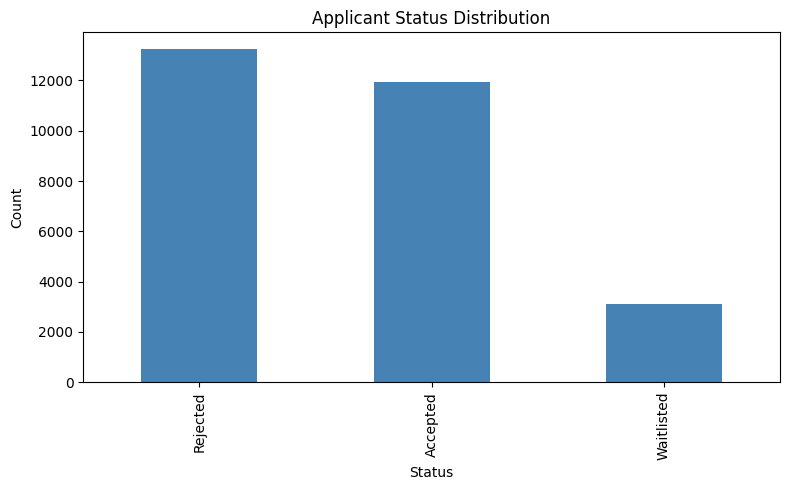

In [24]:
import matplotlib.pyplot as plt

df["applicant_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    color="steelblue"
)

plt.title("Applicant Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

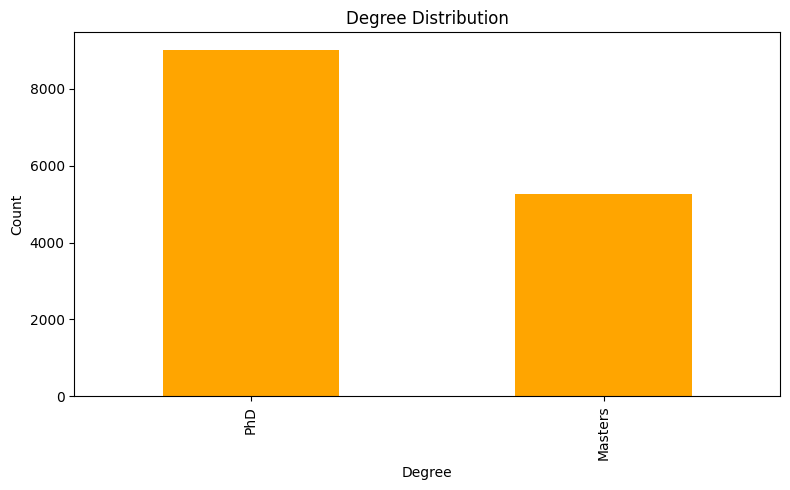

In [25]:
df["degree"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    color="orange"
)

plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

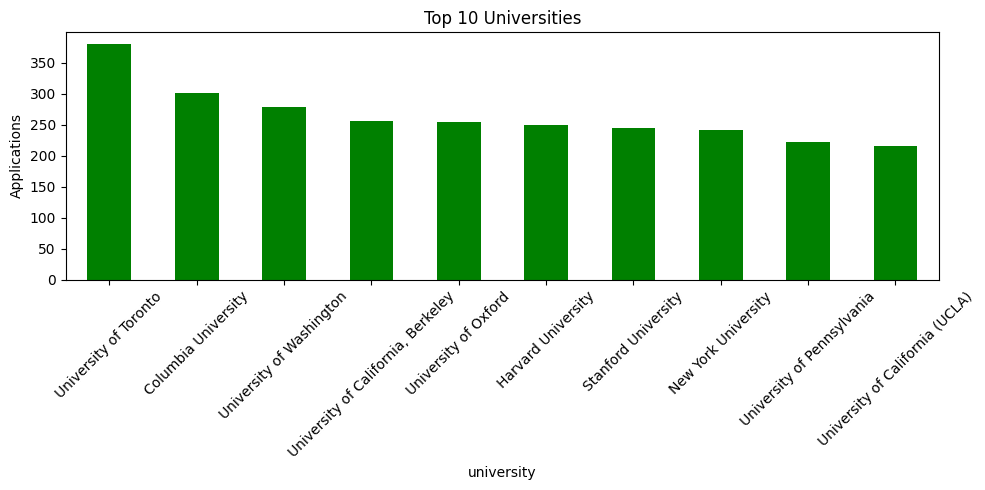

In [26]:
df["university"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    color="green"
)

plt.title("Top 10 Universities")
plt.ylabel("Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

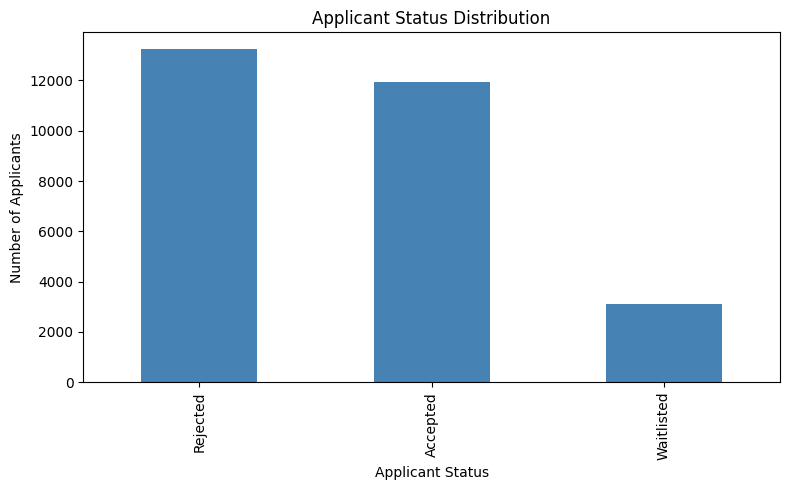

In [27]:
import matplotlib.pyplot as plt

df["applicant_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    color="steelblue"
)

plt.title("Applicant Status Distribution")
plt.xlabel("Applicant Status")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.show()

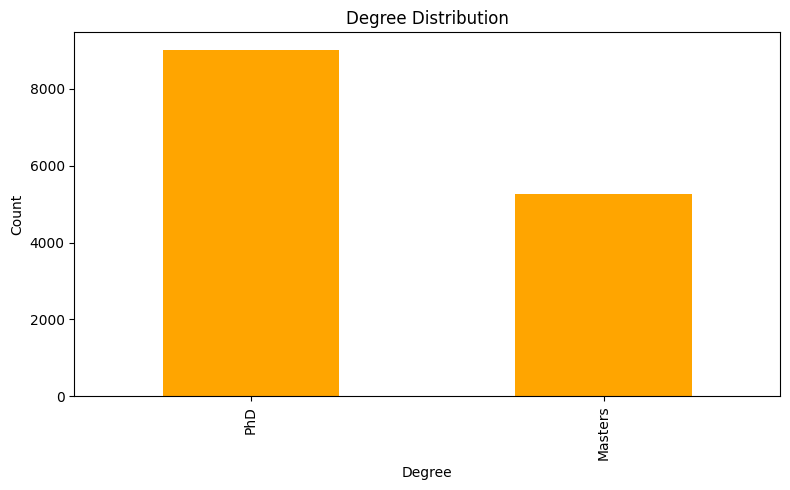

In [28]:
df["degree"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    color="orange"
)

plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


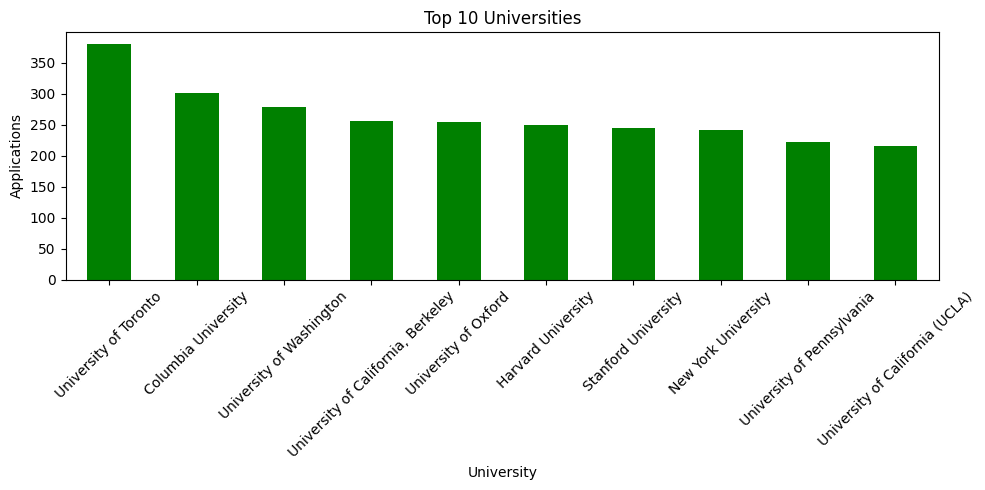

In [29]:
df["university"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    color="green"
)

plt.title("Top 10 Universities")
plt.xlabel("University")
plt.ylabel("Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Statistical Hypothesis Test


In [31]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["applicant_status"], df["student_type"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 29.101703636695756
P-value: 4.793418506761273e-07
Degrees of freedom: 2


In [46]:
# Preserve the untouched dataset before cleaning
raw_df = df.copy(deep=True)

raw_row_count = raw_df.shape[0]
raw_column_count = raw_df.shape[1]

print("Raw rows:", raw_row_count)
print("Raw columns:", raw_column_count)

print("\nColumn names:")
print(raw_df.columns.tolist())

print("\nData types:")
display(raw_df.dtypes)

print("\nFirst five raw rows:")
display(raw_df.head())


Raw rows: 29609
Raw columns: 17

Column names:
['program_name', 'university', 'comments', 'date_added', 'entry_url', 'applicant_status', 'acceptance_date', 'rejection_date', 'start_term', 'student_type', 'gre_score', 'gre_v_score', 'degree', 'gpa', 'gre_aw', 'raw_listing', 'source_page']

Data types:


program_name        string[python]
university          string[python]
comments            string[python]
date_added                  object
entry_url                   object
applicant_status    string[python]
acceptance_date             object
rejection_date              object
start_term          string[python]
student_type        string[python]
gre_score                   object
gre_v_score                 object
degree              string[python]
gpa                         object
gre_aw                      object
raw_listing                 object
source_page                 object
dtype: object


First five raw rows:


,program_name,university,comments,date_added,entry_url,applicant_status,acceptance_date,rejection_date,start_term,student_type,gre_score,gre_v_score,degree,gpa,gre_aw,raw_listing,source_page
0,Stockholm University,Stockholm University,<NA>,Stockholm University,https://www.thegradcafe.com/result/1020288,Accepted,May 31,None,<NA>,<NA>,None,None,PhD,None,None,Stockholm University Environmental Economics P...,https://www.thegradcafe.com/survey?page=1&sort...
1,Accepted on May 31 Fall 2026 International,Accepted on May 31 Fall 2026 International,<NA>,Accepted on May 31,https://www.thegradcafe.com/survey?page=1&sort...,Accepted,May 31,None,Fall 2026,International,None,None,<NA>,None,None,Accepted on May 31 Fall 2026 International,https://www.thegradcafe.com/survey?page=1&sort...
2,Meharry Medical College,Meharry Medical College,<NA>,Meharry Medical College,https://www.thegradcafe.com/result/1020287,Accepted,May 29,None,<NA>,<NA>,None,None,PhD,None,None,Meharry Medical College Global Health PhD May ...,https://www.thegradcafe.com/survey?page=1&sort...
3,Accepted on May 29 Fall 2026 American GPA 3.90,Accepted on May 29 Fall 2026 American GPA 3.90,<NA>,Accepted on May 29,https://www.thegradcafe.com/survey?page=1&sort...,Accepted,May 29,None,Fall 2026,American,None,None,<NA>,3.90,None,Accepted on May 29 Fall 2026 American GPA 3.90,https://www.thegradcafe.com/survey?page=1&sort...
4,University of Massachusetts,University of Massachusetts,<NA>,University of Massachusetts,https://www.thegradcafe.com/result/1020286,Waitlisted,None,None,<NA>,<NA>,None,None,PhD,None,None,University of Massachusetts Public Policy PhD ...,https://www.thegradcafe.com/survey?page=1&sort...


## 7. Export Cleaned Dataset

In [32]:
cleaned_file = "cleaned_applicant_data.csv"

df.to_csv(cleaned_file, index=False)

print("Saved:", cleaned_file)

Saved: cleaned_applicant_data.csv


In [33]:
import os

print(os.path.getsize(cleaned_file) / 1024 / 1024, "MB")

8.459945678710938 MB


In [34]:
s3.upload_file(
    cleaned_file,
    bucket_name,
    "cleaned_applicant_data.csv"
)

print("Uploaded cleaned dataset to S3.")

Uploaded cleaned dataset to S3.


In [35]:
response = s3.list_objects_v2(Bucket=bucket_name)

for obj in response["Contents"]:
    print(obj["Key"])

applicant_data.json
cleaned_applicant_data.csv


In [ ]:
import pandas as pd

df = pd.DataFrame(data)

df.head()

response = s3.list_objects_v2(Bucket=bucket_name)

for obj in response["Contents"]:
    print(obj["Key"])

In [37]:
raw_df = df.copy()

print(raw_df.shape)


(30000, 17)


In [38]:
print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

print("\nColumn Names")
print(raw_df.columns.tolist())

print("\nData Types")
print(raw_df.dtypes)

Rows: 30000
Columns: 17

Column Names
['program_name', 'university', 'comments', 'date_added', 'entry_url', 'applicant_status', 'acceptance_date', 'rejection_date', 'start_term', 'student_type', 'gre_score', 'gre_v_score', 'degree', 'gpa', 'gre_aw', 'raw_listing', 'source_page']

Data Types
program_name        object
university          object
comments            object
date_added          object
entry_url           object
applicant_status    object
acceptance_date     object
rejection_date      object
start_term          object
student_type        object
gre_score           object
gre_v_score         object
degree              object
gpa                 object
gre_aw              object
raw_listing         object
source_page         object
dtype: object


In [39]:
df = raw_df.dropna(subset=["program_name"])

print(df.shape)

(29609, 17)


In [40]:
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
program_name,0,0.00
university,0,0.00
comments,29609,100.00
date_added,0,0.00
entry_url,0,0.00
applicant_status,0,0.00
acceptance_date,17471,59.01
rejection_date,15250,51.50
start_term,14805,50.00
student_type,15029,50.76


In [41]:
missing_summary.to_csv("missingness_summary.csv")

print("Saved missingness_summary.csv")

Saved missingness_summary.csv


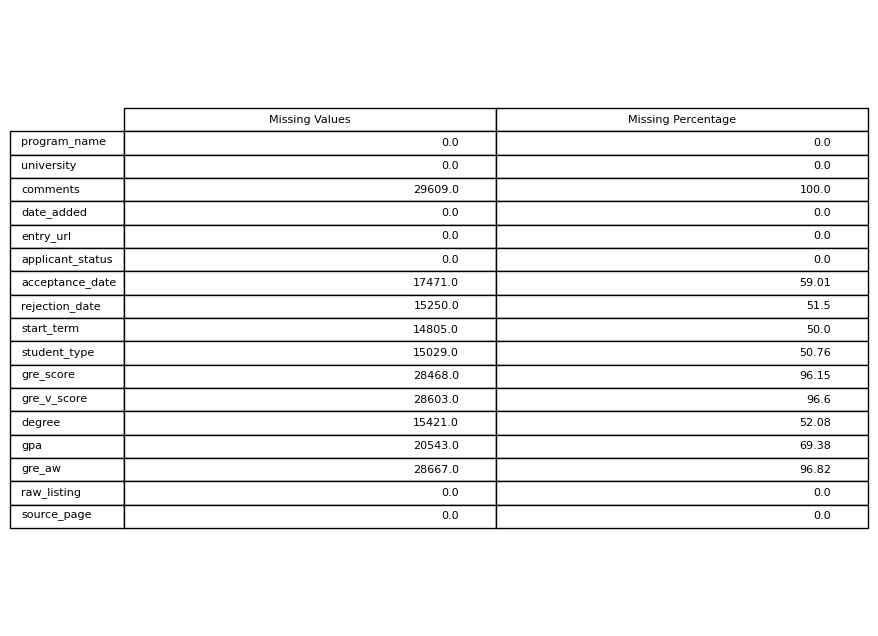

In [42]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

ax.axis("off")

table = ax.table(
    cellText=missing_summary.values,
    colLabels=missing_summary.columns,
    rowLabels=missing_summary.index,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2,1.4)

plt.savefig("missingness_summary.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [43]:
raw_df = df.copy()

print("Before:", raw_df.shape)

df = raw_df.dropna(subset=["program_name"])

print("After:", df.shape)

Before: (29609, 17)
After: (29609, 17)


In [44]:
print(df["program_name"].isna().sum())

0


Note: The downloaded Grad Café dataset already contains separate program_name and university fields. Therefore, no additional splitting was required. The notebook only removed rows where program_name was missing.

## 4.1 Clean Text Columns and Count Rare Programs

Text columns are stripped of leading and trailing whitespace, and repeated internal whitespace is collapsed. Program frequencies are then calculated, and programs appearing fewer than three times are identified.

In [6]:
# Inspect suspicious program_name values before cleaning
status_pattern = r"(?i)\b(accepted|rejected|wait\s*listed|waitlisted)\b"

suspicious_programs = df[
    df["program_name"].astype("string").str.contains(
        status_pattern, regex=True, na=False
    )
]

print("Total rows:", len(df))
print("Suspicious program_name rows:", len(suspicious_programs))
print(
    "Suspicious percentage:",
    round(len(suspicious_programs) / len(df) * 100, 2),
    "%"
)

display(
    suspicious_programs[
        [
            "program_name",
            "university",
            "applicant_status",
            "degree",
            "gpa"
        ]
    ].head(20)
)

Total rows: 27894
Suspicious program_name rows: 13089
Suspicious percentage: 46.92 %


C:\Users\amr.mansour\AppData\Local\Temp\ipykernel_56948\19627241.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["program_name"].astype("string").str.contains(


,program_name,university,applicant_status,degree,gpa
1,Accepted on May 31 Fall 2026 International,Accepted on May 31 Fall 2026 International,Accepted,<NA>,NaN
3,Accepted on May 29 Fall 2026 American GPA 3.90,Accepted on May 29 Fall 2026 American GPA 3.90,Accepted,<NA>,3.90
5,Wait listed on May 29 Fall 2026 International,Wait listed on May 29 Fall 2026 International,Waitlisted,<NA>,NaN
7,Accepted on Apr 17 Fall 2026 Other,Accepted on Apr 17 Fall 2026 Other,Accepted,<NA>,NaN
9,Accepted on May 08 Fall 2026 International GPA...,Accepted on May 08 Fall 2026 International GPA...,Accepted,<NA>,3.84
11,Rejected on May 29 Fall 2026 American GPA 3.90,Rejected on May 29 Fall 2026 American GPA 3.90,Rejected,<NA>,3.90
13,Wait listed on May 29 Fall 2026 International ...,Wait listed on May 29 Fall 2026 International ...,Waitlisted,<NA>,3.50
15,Accepted on May 25 Fall 2026 International,Accepted on May 25 Fall 2026 International,Accepted,<NA>,NaN
17,Accepted on May 15 Fall 2026 International GPA...,Accepted on May 15 Fall 2026 International GPA...,Accepted,<NA>,3.84
19,Rejected on May 28 Fall 2026 Other GPA 3.50,Rejected on May 28 Fall 2026 Other GPA 3.50,Rejected,<NA>,3.50


In [7]:
# Inspect original raw listings for corrupted rows
status_pattern = r"(?i)\b(?:accepted|rejected|wait\s*listed|waitlisted)\b"

bad_mask = df["program_name"].astype("string").str.contains(
    status_pattern,
    regex=True,
    na=False
)

print("Corrupted rows:", bad_mask.sum())
print("\nSample original raw listings:\n")

for idx in df.index[bad_mask][:10]:
    print("=" * 80)
    print("ROW:", idx)
    print("program_name:", df.loc[idx, "program_name"])
    print("university:", df.loc[idx, "university"])
    print("raw_listing:")
    print(df.loc[idx, "raw_listing"])
    print()

Corrupted rows: 13089

Sample original raw listings:

ROW: 1
program_name: Accepted on May 31 Fall 2026 International
university: Accepted on May 31 Fall 2026 International
raw_listing:
Accepted on May 31 Fall 2026 International

ROW: 3
program_name: Accepted on May 29 Fall 2026 American GPA 3.90
university: Accepted on May 29 Fall 2026 American GPA 3.90
raw_listing:
Accepted on May 29 Fall 2026 American GPA 3.90

ROW: 5
program_name: Wait listed on May 29 Fall 2026 International
university: Wait listed on May 29 Fall 2026 International
raw_listing:
Wait listed on May 29 Fall 2026 International

ROW: 7
program_name: Accepted on Apr 17 Fall 2026 Other
university: Accepted on Apr 17 Fall 2026 Other
raw_listing:
Accepted on Apr 17 Fall 2026 Other

ROW: 9
program_name: Accepted on May 08 Fall 2026 International GPA 3.84
university: Accepted on May 08 Fall 2026 International GPA 3.84
raw_listing:
Accepted on May 08 Fall 2026 International GPA 3.84

ROW: 11
program_name: Rejected on May 29 F

In [8]:
# Correct corrupted program/university fields while preserving the records

status_pattern = r"(?i)\b(?:accepted|rejected|wait\s*listed|waitlisted)\b"

bad_program = df["program_name"].astype("string").str.contains(
    status_pattern, regex=True, na=False
)

bad_university = df["university"].astype("string").str.contains(
    status_pattern, regex=True, na=False
)

print("Rows before cleaning:", len(df))
print("Corrupted program_name values:", bad_program.sum())
print("Corrupted university values:", bad_university.sum())

# Do not discard the records.
# Only invalidate fields that clearly contain admission-result text.
df.loc[bad_program, "program_name"] = pd.NA
df.loc[bad_university, "university"] = pd.NA

print("\nRows after cleaning:", len(df))
print("Valid program_name values:", df["program_name"].notna().sum())
print("Missing program_name values:", df["program_name"].isna().sum())
print("Valid university values:", df["university"].notna().sum())
print("Missing university values:", df["university"].isna().sum())

# Confirm that decision text is no longer treated as a program
remaining_bad = df["program_name"].astype("string").str.contains(
    status_pattern, regex=True, na=False
).sum()

print("Remaining corrupted program names:", remaining_bad)

Rows before cleaning: 27894
Corrupted program_name values: 13089
Corrupted university values: 13089

Rows after cleaning: 27894
Valid program_name values: 14805
Missing program_name values: 13089
Valid university values: 14805
Missing university values: 13089
Remaining corrupted program names: 0


In [9]:
# Recalculate program frequencies after data-quality correction

valid_programs = df["program_name"].dropna()

program_counts = valid_programs.value_counts()

low_program_count = program_counts[program_counts < 3]

print("Total records:", len(df))
print("Records with valid program names:", len(valid_programs))
print("Unique valid programs:", program_counts.size)
print("Programs occurring fewer than 3 times:", len(low_program_count))

display(low_program_count.head(20))

Total records: 27894
Records with valid program names: 14805
Unique valid programs: 1145
Programs occurring fewer than 3 times: 662


program_name
Xavier University                            2
Hollins University                           2
Southern Illinois University-Edwardsville    2
Georgia Tech                                 2
University of South Dakota                   2
University of Nebraska Lincoln               2
Florida Institute of Technology              2
University of North Dakota                   2
Tinbergen Institute                          2
Monmouth University                          2
UMass Boston                                 2
Ontario Tech University                      2
University of California Irvine              2
Massachusetts Institute of Technology        2
Sarah Lawrence                               2
Fairfield University                         2
University of Findlay                        2
Georgetown College                           2
Cranbrook Academy of Art                     2
Princeton                                    2
Name: count, dtype: Int64

In [5]:
import pandas as pd

raw_df = pd.read_csv("cleaned_applicant_data.csv")
df = raw_df.dropna(subset=["program_name"]).copy()

print("Data restored:", df.shape)

# Work from the cleaned copy
text_columns = [
    "program_name",
    "university",
    "comments",
    "applicant_status",
    "start_term",
    "student_type",
    "degree",
]

for column in text_columns:
    if column in df.columns:
        df[column] = (
            df[column]
            .astype("string")
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

# Count each unique program
program_counts = df["program_name"].value_counts(dropna=False)

# Programs occurring fewer than 3 times
low_program_count = program_counts[program_counts < 3]

print("Unique programs:", program_counts.size)
print("Programs occurring fewer than 3 times:", len(low_program_count))

display(low_program_count)

Data restored: (27894, 17)
Unique programs: 8364
Programs occurring fewer than 3 times: 7022


program_name
Rejected on Mar 13 Fall 2026 American GPA 3.95            2
Rejected on Mar 11 Fall 2026 International GPA 3.95       2
Accepted on Mar 24 Fall 2026 American GPA 3.93            2
Wait listed on Apr 01 Fall 2026 International GPA 4.00    2
Rejected on Mar 09 Fall 2026 American GPA 3.95            2
                                                         ..
Azusa Pacific University                                  1
Rejected on May 29 Fall 2026 American GPA 3.90            1
Rejected on Feb 19 Fall 2026 International GPA 3.65       1
Accepted on Feb 19 Fall 2026 American GPA 3.85            1
Rejected on May 27 Fall 2026 American GPA 4.00            1
Name: count, Length: 7022, dtype: Int64

In [47]:
missingness_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missingness_summary)

missingness_summary.to_csv("missingness_summary.csv")

print("missingness_summary.csv saved")

,Missing Values,Missing Percentage
program_name,0,0.00
university,0,0.00
comments,29609,100.00
date_added,0,0.00
entry_url,0,0.00
applicant_status,0,0.00
acceptance_date,17471,59.01
rejection_date,15250,51.50
start_term,14805,50.00
student_type,15029,50.76


missingness_summary.csv saved


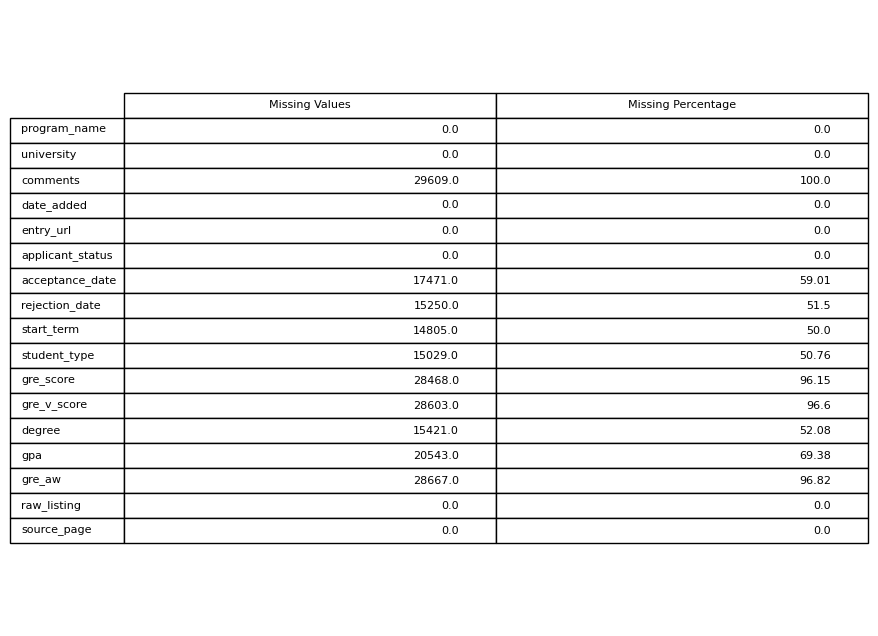

missingness_summary.png saved


In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

ax.axis("off")

table = ax.table(
    cellText=missingness_summary.values,
    rowLabels=missingness_summary.index,
    colLabels=missingness_summary.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)

plt.savefig("missingness_summary.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

print("missingness_summary.png saved")

In [49]:
import os

print(os.path.exists("missingness_summary.csv"))
print(os.path.exists("missingness_summary.png"))

True
True


In [13]:
numeric_cols = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

summary_statistics = df[numeric_cols].describe().T
display(summary_statistics)

summary_statistics.to_csv("summary_statistics.csv")

print("summary_statistics.csv saved.")

,count,mean,std,min,25%,50%,75%,max
gpa,8748.0,3.765863,0.365535,0.42,3.63,3.82,3.94,9.99
gre_score,1124.0,253.569395,80.414385,139.00,168.00,309.00,327.00,655.00
gre_v_score,990.0,160.457576,6.123907,134.00,156.00,161.00,165.00,170.00
gre_aw,926.0,7.627948,17.501047,2.00,4.00,4.50,5.00,99.99


summary_statistics.csv saved.


In [14]:
from scipy.stats import zscore
import numpy as np

# GPA outliers
df["gpa_outlier"] = False

mask = df["gpa"].notna()

df.loc[mask, "gpa_outlier"] = (
    np.abs(zscore(df.loc[mask, "gpa"])) > 3
)

# GRE outliers
df["gre_outlier"] = False

mask = df["gre_score"].notna()

df.loc[mask, "gre_outlier"] = (
    np.abs(zscore(df.loc[mask, "gre_score"])) > 3
)

print("GPA Outliers:", df["gpa_outlier"].sum())
print("GRE Outliers:", df["gre_outlier"].sum())

GPA Outliers: 33
GRE Outliers: 1


In [12]:
import pandas as pd
import numpy as np

# Make all analytical numeric fields numeric once
numeric_cols = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Make date fields usable
date_cols = ["date_added", "acceptance_date", "rejection_date"]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("DATA PREPARATION COMPLETE")
print("Rows:", len(df))
print("\nNumeric types:")
print(df[numeric_cols].dtypes)
print("\nRemaining numeric conversion check:")
print(df[numeric_cols].apply(lambda x: x.dropna().map(
    lambda v: isinstance(v, (int, float, np.number))
).all()))

DATA PREPARATION COMPLETE
Rows: 27894

Numeric types:
gpa            float64
gre_score      float64
gre_v_score    float64
gre_aw         float64
dtype: object

Remaining numeric conversion check:
gpa            True
gre_score      True
gre_v_score    True
gre_aw         True
dtype: bool


C:\Users\amr.mansour\AppData\Local\Temp\ipykernel_56948\215751964.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\amr.mansour\AppData\Local\Temp\ipykernel_56948\215751964.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")
C:\Users\amr.mansour\AppData\Local\Temp\ipykernel_56948\215751964.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [52]:
numeric_columns = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

for column in numeric_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.extract(r"([-+]?\d*\.?\d+)", expand=False)
    )

    df[column] = pd.to_numeric(df[column], errors="coerce")

print(df[numeric_columns].dtypes)
display(df[numeric_columns].head(10))

gpa            Float64
gre_score        Int64
gre_v_score      Int64
gre_aw         Float64
dtype: object


,gpa,gre_score,gre_v_score,gre_aw
0,<NA>,<NA>,<NA>,<NA>
1,<NA>,<NA>,<NA>,<NA>
2,<NA>,<NA>,<NA>,<NA>
3,3.9,<NA>,<NA>,<NA>
4,<NA>,<NA>,<NA>,<NA>
5,<NA>,<NA>,<NA>,<NA>
6,<NA>,<NA>,<NA>,<NA>
7,<NA>,<NA>,<NA>,<NA>
8,<NA>,<NA>,<NA>,<NA>
9,3.84,<NA>,<NA>,<NA>


In [53]:
numeric_cols = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

summary_statistics = df[numeric_cols].describe().T[
    ["count", "mean", "50%", "std", "min", "25%", "75%", "max"]
]

summary_statistics.rename(columns={"50%": "median"}, inplace=True)

display(summary_statistics)

summary_statistics.to_csv("summary_statistics.csv")

,count,mean,median,std,min,25%,75%,max
gpa,9066.0,3.767502,3.82,0.361846,0.42,3.64,3.94,9.99
gre_score,1141.0,253.966696,309.0,80.405315,139.0,168.0,327.0,655.0
gre_v_score,1006.0,160.492048,161.0,6.136542,134.0,156.0,165.0,170.0
gre_aw,942.0,7.57482,4.5,17.356655,2.0,4.0,5.0,99.99


In [54]:
from scipy.stats import zscore
import numpy as np

df["gpa_outlier"] = False
mask = df["gpa"].notna()
df.loc[mask, "gpa_outlier"] = np.abs(zscore(df.loc[mask, "gpa"])) > 3

df["gre_outlier"] = False
mask = df["gre_score"].notna()
df.loc[mask, "gre_outlier"] = np.abs(zscore(df.loc[mask, "gre_score"])) > 3

print("GPA outliers:", df["gpa_outlier"].sum())
print("GRE outliers:", df["gre_outlier"].sum())

GPA outliers: 34
GRE outliers: 1


In [56]:
from scipy.stats import pearsonr, spearmanr

# GRE vs GRE V (Pearson)
corr_df = df[["gre_score", "gre_v_score"]].dropna()

r1, p1 = pearsonr(corr_df["gre_score"], corr_df["gre_v_score"])

print("GRE vs GRE V")
print("Pearson correlation:", round(r1, 4))
print("P-value:", p1)

GRE vs GRE V
Pearson correlation: 0.0103
P-value: 0.7480665729968377


In [57]:
# GPA vs GRE (Pearson)

corr_df2 = df[["gpa", "gre_score"]].dropna()

r2, p2 = pearsonr(corr_df2["gpa"], corr_df2["gre_score"])

print("GPA vs GRE")
print("Pearson correlation:", round(r2,4))
print("P-value:", p2)

GPA vs GRE
Pearson correlation: -0.0259
P-value: 0.4056768286587448


In [59]:
from scipy.stats import ttest_ind

accepted = df.loc[
    (df["applicant_status"] == "Accepted") &
    (df["gpa"].notna()),
    "gpa"
]

rejected = df.loc[
    (df["applicant_status"] == "Rejected") &
    (df["gpa"].notna()),
    "gpa"
]

t_stat, p_value = ttest_ind(
    accepted,
    rejected,
    equal_var=False,
    nan_policy="omit"
)

print("Accepted GPA count:", len(accepted))
print("Rejected GPA count:", len(rejected))
print("Accepted mean GPA:", accepted.mean())
print("Rejected mean GPA:", rejected.mean())
print("T statistic:", t_stat)
print("P-value:", p_value)

Accepted GPA count: 4119
Rejected GPA count: 4169
Accepted mean GPA: 3.759502306385045
Rejected mean GPA: 3.7728352122811226
T statistic: -1.6528591737450096
P-value: 0.0983991933205626


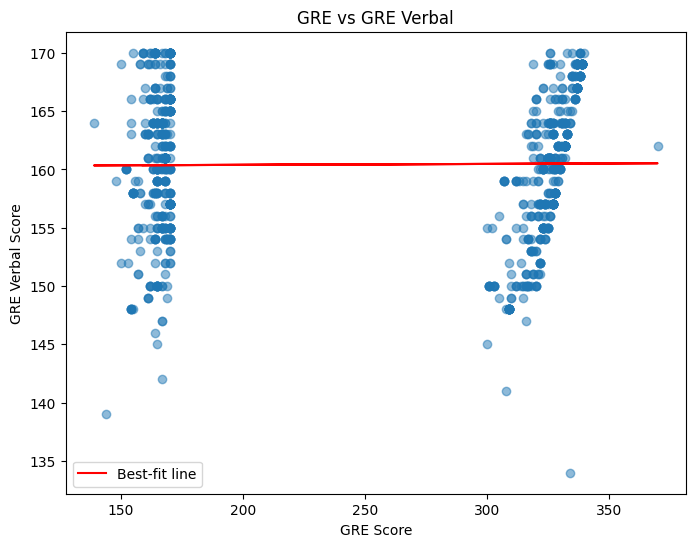

In [60]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = df[(df["gre_score"] > 0) & (df["gre_v_score"] > 0)]

plt.figure(figsize=(8,6))
plt.scatter(plot_df["gre_score"], plot_df["gre_v_score"], alpha=0.5)

z = np.polyfit(plot_df["gre_score"], plot_df["gre_v_score"], 1)
p = np.poly1d(z)
plt.plot(plot_df["gre_score"], p(plot_df["gre_score"]),
         color="red", label="Best-fit line")

plt.title("GRE vs GRE Verbal")
plt.xlabel("GRE Score")
plt.ylabel("GRE Verbal Score")
plt.legend()

plt.savefig("GRE-vs-GRE-V.png", dpi=300, bbox_inches="tight")
plt.show()

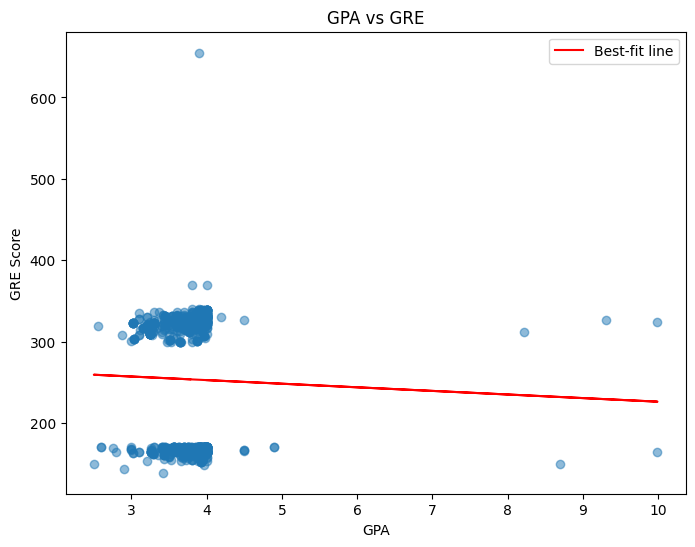

In [61]:
plot_df = df[(df["gpa"] > 0) & (df["gre_score"] > 0)]

plt.figure(figsize=(8,6))
plt.scatter(plot_df["gpa"], plot_df["gre_score"], alpha=0.5)

z = np.polyfit(plot_df["gpa"], plot_df["gre_score"], 1)
p = np.poly1d(z)

plt.plot(plot_df["gpa"], p(plot_df["gpa"]),
         color="red", label="Best-fit line")

plt.title("GPA vs GRE")
plt.xlabel("GPA")
plt.ylabel("GRE Score")
plt.legend()

plt.savefig("GPA-vs-GRE.png", dpi=300, bbox_inches="tight")
plt.show()

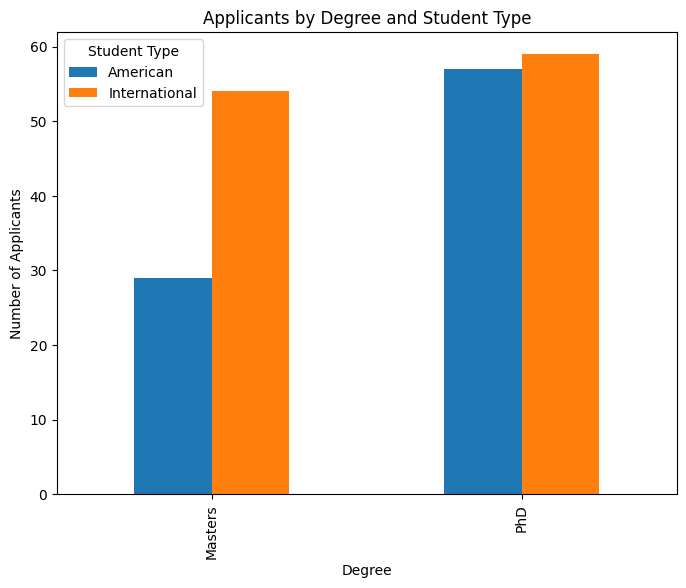

In [62]:
table = pd.crosstab(df["degree"], df["student_type"])

table.plot(kind="bar", figsize=(8,6))

plt.title("Applicants by Degree and Student Type")
plt.xlabel("Degree")
plt.ylabel("Number of Applicants")
plt.legend(title="Student Type")

plt.savefig("Degree-vs-International.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [67]:
# Standardize the required outcome column
outcome_map = {
    "accepted": "Accepted",
    "rejected": "Rejected",
    "waitlisted": "Waitlisted",
    "wait listed": "Waitlisted",
    "interviewed": "Interviewed",
}

df["outcome"] = (
    df["applicant_status"]
    .astype("string")
    .str.strip()
    .str.lower()
    .map(outcome_map)
)

# Infer the year from start_term, such as "Fall 2026"
decision_year = (
    df["start_term"]
    .astype("string")
    .str.extract(r"(20\d{2})", expand=False)
)

# Choose the appropriate decision-date text
decision_text = pd.Series(pd.NA, index=df.index, dtype="string")

decision_text.loc[df["outcome"] == "Accepted"] = (
    df.loc[df["outcome"] == "Accepted", "acceptance_date"]
    .astype("string")
)

decision_text.loc[df["outcome"] == "Rejected"] = (
    df.loc[df["outcome"] == "Rejected", "rejection_date"]
    .astype("string")
)

# Combine month/day with the inferred year and convert to datetime
full_decision_date = decision_text.str.cat(decision_year, sep=" ")

df["decision_date"] = pd.to_datetime(
    full_decision_date,
    format="%b %d %Y",
    errors="coerce"
)

print(df[[
    "applicant_status",
    "outcome",
    "acceptance_date",
    "rejection_date",
    "start_term",
    "decision_date",
]].head(15))

print("\nValid decision dates:", df["decision_date"].notna().sum())

   applicant_status     outcome acceptance_date rejection_date start_term  \
0          Accepted    Accepted          May 31           None       <NA>   
1          Accepted    Accepted          May 31           None  Fall 2026   
2          Accepted    Accepted          May 29           None       <NA>   
3          Accepted    Accepted          May 29           None  Fall 2026   
4        Waitlisted  Waitlisted            None           None       <NA>   
5        Waitlisted  Waitlisted            None           None  Fall 2026   
6          Accepted    Accepted          Apr 17           None       <NA>   
7          Accepted    Accepted          Apr 17           None  Fall 2026   
8          Accepted    Accepted          May 08           None       <NA>   
9          Accepted    Accepted          May 08           None  Fall 2026   
10         Rejected    Rejected            None         May 29       <NA>   
11         Rejected    Rejected            None         May 29  Fall 2026   

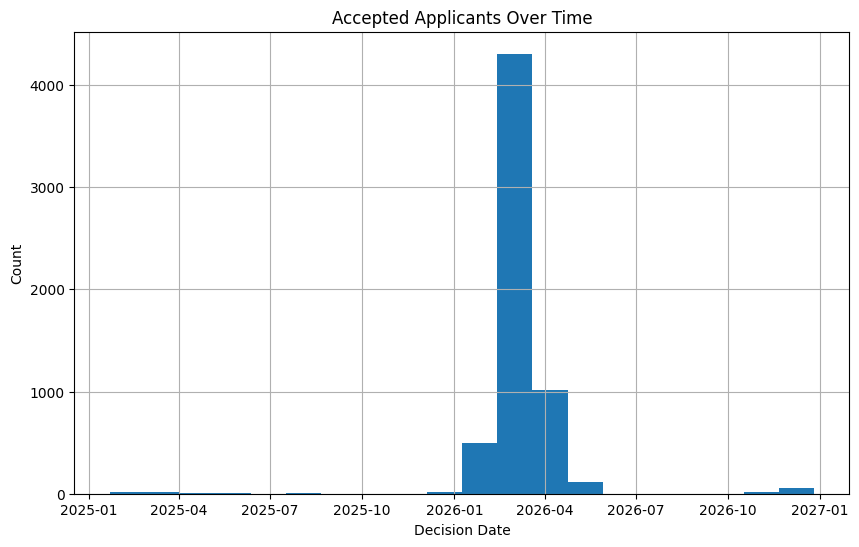

In [68]:
accepted = df[
    (df["applicant_status"]=="Accepted") &
    (df["decision_date"].notna())
]

plt.figure(figsize=(10,6))

accepted["decision_date"].hist(bins=20)

plt.title("Accepted Applicants Over Time")
plt.xlabel("Decision Date")
plt.ylabel("Count")

plt.savefig("Acceptances-over-Time.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

<Figure size 800x600 with 0 Axes>

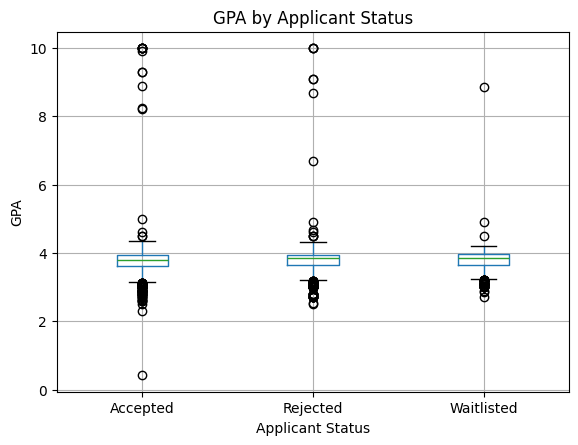

In [65]:
plt.figure(figsize=(8,6))

df.boxplot(column="gpa", by="applicant_status")

plt.title("GPA by Applicant Status")
plt.suptitle("")
plt.xlabel("Applicant Status")
plt.ylabel("GPA")

plt.savefig("GPA-by-Outcome.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

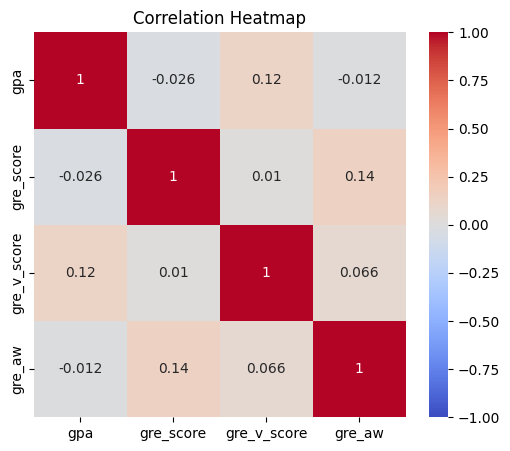

In [66]:
import seaborn as sns

corr = df[
    ["gpa","gre_score","gre_v_score","gre_aw"]
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Heatmap")

plt.savefig(
    "Numeric-Correlation-Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
phd_gre = df[
    (df["degree"] == "PhD") &
    (df["applicant_status"] == "Accepted")
]["gre_score"].mean()

print("Average GRE (Accepted PhD):", phd_gre)

Average GRE (Accepted PhD): <NA>


In [70]:
masters_gpa = df[
    (df["degree"] == "Masters") &
    (df["applicant_status"] == "Accepted")
]["gpa"].mean()

print("Average GPA (Accepted Masters):", masters_gpa)

Average GPA (Accepted Masters): <NA>


In [71]:
print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 29.101703636695756
P-value:  
-4.416 x + 270.4


In [72]:
df[
    (df["degree"] == "PhD") &
    (df["applicant_status"] == "Accepted")
][["gre_score"]].describe()

,gre_score
count,0.0
mean,<NA>
std,<NA>
min,<NA>
25%,<NA>
50%,<NA>
75%,<NA>
max,<NA>


In [73]:
df[
    (df["degree"] == "Masters") &
    (df["applicant_status"] == "Accepted")
][["gpa"]].describe()


,gpa
count,0.0
mean,<NA>
std,<NA>
min,<NA>
25%,<NA>
50%,<NA>
75%,<NA>
max,<NA>


In [74]:
from scipy.stats import chi2_contingency
import pandas as pd

# Remove rows with missing values
chi_df = df.dropna(subset=["degree", "student_type"])

# Create contingency table
contingency = pd.crosstab(
    chi_df["degree"],
    chi_df["student_type"]
)

print("Contingency Table:")
print(contingency)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)

Contingency Table:
student_type  American  International
degree                               
Masters             29             54
PhD                 57             59

Chi-square statistic: 3.416929640092402
Degrees of freedom: 1
P-value: 0.06453092829633826


In [75]:
cleaned_json = "cleaned_gradcafe.json"

df.to_json(
    cleaned_json,
    orient="records",
    indent=4
)

print("Saved:", cleaned_json)


Saved: cleaned_gradcafe.json


In [76]:
s3.upload_file(
    cleaned_json,
    bucket_name,
    "cleaned_gradcafe.json"
)

print("Cleaned JSON uploaded to S3 successfully!")


Cleaned JSON uploaded to S3 successfully!


In [77]:
response = s3.list_objects_v2(Bucket=bucket_name)

print("Files in bucket:")
for obj in response.get("Contents", []):
    print(obj["Key"])

Files in bucket:
applicant_data.json
cleaned_applicant_data.csv
cleaned_gradcafe.json


In [ ]:
date_based.png